In [15]:
import os, pathlib
import numpy as np
import pandas as pd
import laspy
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

In [59]:
!pip install ipywidgets widgetsnbextension pandas-profiling

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 6.9 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 9.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 9.7 MB/s eta 0:00:00ta 0:00:01
  DEPRECATION: Building 'htmlmin' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'htmlmin'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Cr

In [23]:
# ─── paths ──────────────────────────────────────────────────────────────────────
data_root   = pathlib.Path("/Volumes/T7/FORspecies20K/dev")   # top of the un-zipped tree data
meta_csv    = data_root / "kept_file_ids.csv"
out_dir     = pathlib.Path("/Volumes/T7/FORspecies20K/preprocessed_128")
out_dir.mkdir(exist_ok=True)



# ─── 1. read & filter metadata ─────────────────────────────────────────────────
meta = pd.read_csv("kept_file_ids.csv")
      # height column is “tree_H” in metres


In [ ]:


def rasterize_multi_channel(points, res=32, margin=0.05, flip_v_axis=False):
    """
    Creates a 3-channel "rich" image from a top-down view of a point cloud.
    Channel 1: Density
    Channel 2: Normalized Mean Height (Z)
    Channel 3: Normalized Std Dev of Height (Z)
    """
    if points.shape[0] == 0:
        return Image.fromarray(np.zeros((res, res, 3), dtype=np.uint8), mode="RGB")

    # Project points to the XY plane and get their Z values
    xy = points[:, [0, 1]]
    z = points[:, 2]
    
    mn, mx = xy.min(0), xy.max(0)
    z_min, z_max = z.min(), z.max()

    span = mx - mn
    span[span == 0] = 1
    span_with_margin = span * (1 + margin * 2)

    # Digitize points into grid coordinates
    pix = np.floor(((xy - mn + span * margin) / span_with_margin) * res).astype(int)
    pix = np.clip(pix, 0, res - 1)

    if flip_v_axis:
        pix[:, 1] = (res - 1) - pix[:, 1]

    # Create canvases for each property
    density_map = np.zeros((res, res), dtype=np.float32)
    mean_z_map = np.zeros((res, res), dtype=np.float32)
    std_z_map = np.zeros((res, res), dtype=np.float32)

    # Use a dictionary or pandas for easier grouping
    # This is more readable than complex numpy indexing for this task
    pixel_groups = {}
    for i, (px, py) in enumerate(pix):
        key = (py, px) # Use (row, col) convention
        if key not in pixel_groups:
            pixel_groups[key] = []
        pixel_groups[key].append(z[i])
        
    for (py, px), z_values in pixel_groups.items():
        density_map[py, px] = len(z_values)
        mean_z_map[py, px] = np.mean(z_values)
        std_z_map[py, px] = np.std(z_values)

    # --- Normalize each channel to [0, 255] ---
    
    # 1. Density (Log-scaled)
    density_map = np.log1p(density_map)
    max_density = density_map.max()
    if max_density > 0:
        density_map = (density_map / max_density) * 255

    # 2. Mean Height (Linearly scaled from min Z to max Z of the whole tree)
    # This preserves absolute height information
    mean_z_map[mean_z_map > 0] = ((mean_z_map[mean_z_map > 0] - z_min) / (z_max - z_min + 1e-6)) * 255

    # 3. Std Dev Height (Scaled by its own max)
    max_std = std_z_map.max()
    if max_std > 0:
        std_z_map = (std_z_map / max_std) * 255
        
    # Stack channels into an RGB-like image
    rgb_image = np.stack([
        density_map,
        mean_z_map,
        std_z_map
    ], axis=-1).astype(np.uint8)

    return Image.fromarray(rgb_image, mode="RGB")


# --- Example Usage ---
# input_view = rasterize_multi_channel(my_tree_points, res=32)



In [19]:
def rasterize_density(points, ax1, ax2, res=64, margin=0.05, contrast='log', flip_v_axis=False):
    """
    Creates a density map directly at the target resolution.
    
    Args:
        points (np.array): Nx3 point cloud.
        ax1 (int): Index for the horizontal axis (e.g., 0 for X).
        ax2 (int): Index for the vertical axis (e.g., 2 for Z).
        res (int): Output resolution of the image.
        margin (float): Percentage margin around the points.
        contrast (str): Contrast enhancement method ('log', 'sqrt', 'linear').
        flip_v_axis (bool): If True, flips the vertical axis so that low values
                            in the point cloud map to the bottom of the image.
    """
    if points.shape[0] == 0:
        return Image.fromarray(np.zeros((res, res), dtype=np.uint8), mode="L")

    plane_coords = points[:, [ax1, ax2]]
    mn, mx = plane_coords.min(0), plane_coords.max(0)
    
    span = mx - mn
    span[span == 0] = 1
    span_with_margin = span * (1 + margin * 2)
    
    pix = np.floor(((plane_coords - mn + span * margin) / span_with_margin) * res).astype(int)
    pix = np.clip(pix, 0, res - 1)

    # --- KEY CHANGE FOR FLIPPING ---
    if flip_v_axis:
        # Invert the vertical pixel coordinates (the second specified axis)
        pix[:, 1] = (res - 1) - pix[:, 1]

    canvas = np.zeros((res, res), dtype=np.float32)
    np.add.at(canvas, (pix[:, 1], pix[:, 0]), 1)

    if contrast == "log":
        canvas = np.log1p(canvas)
    elif contrast == "sqrt":
        canvas = np.sqrt(canvas)
    
    max_val = canvas.max()
    if max_val > 0:
        canvas = (canvas / max_val) * 255.0
    
    return Image.fromarray(canvas.astype(np.uint8), mode="L")

In [ ]:
preview = False
for idx, (_, row) in enumerate(tqdm(meta.iterrows(), total=len(meta))):
    rel_path  = row["id"]     # e.g. train/00072.las
    rel_path = str(rel_path).zfill(5)  + ".laz"
    
    las_path = data_root / rel_path              # fall back to .las

    base = pathlib.Path(rel_path).stem               # “00072”
    pts  = laspy.read(las_path).xyz                  # (N,3) float64

    # nadir  = top view  (X-Y plane → axes 0,1)
    # facade = side view (X-Z plane → axes 0,2).
 
    nadir_img = rasterize_multi_channel(pts, res=128, flip_v_axis=True)
    # facade_img = rasterize_density(pts, ax1=0, ax2=2, res=128, flip_v_axis=True)



    if preview and idx == 0:          # show just the first tree
        fig, ax = plt.subplots(1, 2, figsize=(6, 3))
        ax[0].imshow(nadir_img); ax[0].set_title("nadir")
        # ax[1].imshow(facade_img, cmap='gray'); ax[1].set_title("facade")
        for a in ax: a.axis('off')
        plt.show()
        # After you are happy, flip preview to False and re-run.
        break

    nadir_img.save ( out_dir / f"{base}_nadir.png"  )
    # facade_img.save( out_dir / f"{base}_facade.png" )
    

100%|██████████| 11440/11440 [2:28:26<00:00,  1.28it/s]  


## Auditing Image data 

In [64]:
import pandas as pd
import numpy as np
import laspy
from PIL import Image
from pathlib import Path
from tqdm import tqdm

# --- CONFIGURATION ---
DATA_ROOT = Path("dev") 
IMG_DIR   = Path("preprocessed_32")

# --- SCRIPT ---

audit_data = []
facade_files = list(IMG_DIR.glob("*_facade.png"))
print(f"Found {len(facade_files)} facade images to audit.")

for facade_path in tqdm(facade_files):
    # Extract the base ID (e.g., "15370" from "15370_facade.png")
    base_stem_raw = facade_path.stem.replace("_facade", "")
    
    # --- FIX IS HERE ---
    # Format the stem to be 5 digits with leading zeros (e.g., "75" -> "00075")
    base_stem = base_stem_raw.zfill(5)
    
    # Construct the path to the original point cloud file using the formatted stem
    las_path = DATA_ROOT / f"{base_stem}.laz"
    if not las_path.exists():
        las_path = DATA_ROOT / f"{base_stem}.las"

    # If the source point cloud doesn't exist, we can't analyze it.
    if not las_path.exists():
        print(f"Warning: Could not find source .laz/.las for {base_stem}")
        continue
        
    try:
        # --- Metric 1: Original Point Cloud Info ---
        with laspy.open(las_path) as f:
            point_count = f.header.point_count

        # --- The rest of your script is unchanged ---
        facade_img = Image.open(facade_path)
        facade_arr = np.array(facade_img)
        
        mean_val = facade_arr.mean()
        std_val = facade_arr.std()
        sparsity = np.count_nonzero(facade_arr) / facade_arr.size
        
        audit_data.append({
            "id": base_stem, # Store the correctly formatted ID
            "point_count": point_count,
            "sparsity": sparsity,
            "mean_value": mean_val,
            "std_dev": std_val,
        })

    except Exception as e:
        print(f"Could not process {base_stem}. Error: {e}")

# Create a DataFrame for easy analysis
df = pd.DataFrame(audit_data)

# Save the results
output_csv = "facade_dataset_audit.csv"
df.to_csv(output_csv, index=False)
print(f"Audit complete. DataFrame saved to {output_csv}")

Found 12485 facade images to audit.


100%|██████████| 12485/12485 [00:21<00:00, 580.16it/s]

Audit complete. DataFrame saved to facade_dataset_audit.csv


--- Dataset Statistics ---
        point_count      sparsity    mean_value       std_dev
count  1.248500e+04  12485.000000  12485.000000  12485.000000
mean   4.128472e+05      0.333079     51.529293     75.622793
std    1.126004e+06      0.103830     20.835790     14.281309
min    7.200000e+01      0.051758      6.762695     28.851846
25%    1.781800e+04      0.263672     36.797852     66.206864
50%    7.541500e+04      0.333008     49.885742     76.291463
75%    3.282680e+05      0.398438     64.000977     86.550730
max    1.834512e+07      0.705078    129.923828    107.748670

--- Outliers: Lowest Point Count ---
         id  point_count  sparsity  mean_value    std_dev
4905  16436           72  0.051758    7.878906  35.054074
4621  15021          101  0.058594    7.030273  30.122732
4894  14900          215  0.074219    8.813477  34.074358
6548  19525          238  0.098633    9.793945  33.000111
1664  14897          248  0.066406    6.762695  28.851846

--- Visualizing Problematic 

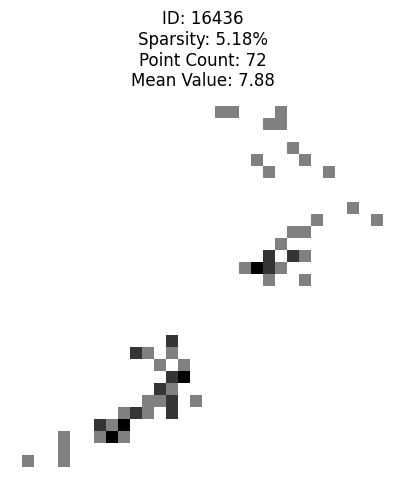

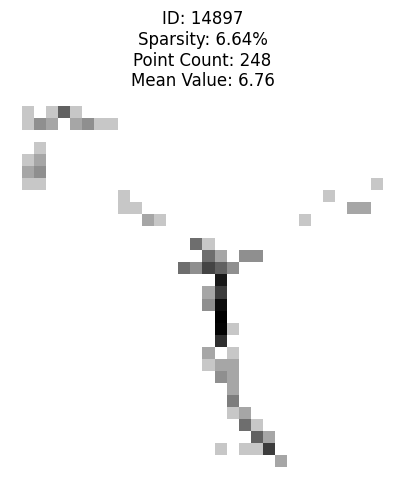

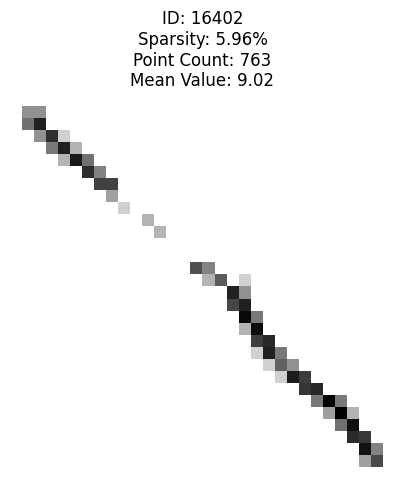

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# --- FIX IS HERE ---
# Load the audit results, explicitly telling pandas to treat 'id' as a string.
df = pd.read_csv("facade_dataset_audit.csv", dtype={'id': str})

# --- The rest of your script now works perfectly ---

# Get a high-level statistical overview
print("--- Dataset Statistics ---")
print(df.describe())

# ... (the rest of your print statements for analysis are fine) ...
print("\n--- Outliers: Lowest Point Count ---")
print(df.sort_values("point_count").head())
blank_images = df[df["sparsity"] == 0]


# --- Visualization Function (Slightly Simplified) ---

IMG_DIR = Path("preprocessed_32")

def visualize_facade(sample_id):
    """Plots the facade image for a given sample ID and shows its stats."""
    # The sample_id is now a string, so the path is constructed correctly.
    facade_path = IMG_DIR / f"{sample_id}_facade.png"
    
    if not facade_path.exists():
        # This will now only trigger if the file is genuinely missing.
        print(f"Image for {sample_id} not found at path: {facade_path}")
        return
        
    facade_img = Image.open(facade_path)
    
    # Get stats from the dataframe (the .astype(str) is no longer needed)
    stats = df[df['id'] == sample_id].iloc[0]

    plt.figure(figsize=(5, 5))
    plt.imshow(facade_img, cmap='gray_r')
    title = (
        f"ID: {sample_id}\n"
        f"Sparsity: {stats.sparsity:.2%}\n"
        f"Point Count: {stats.point_count}\n"
        f"Mean Value: {stats.mean_value:.2f}"
    )
    plt.title(title)
    plt.axis('off')
    plt.show()

# --- Now, visualize the most likely suspects ---

print("\n--- Visualizing Problematic Samples ---")

# Visualize a sample with an extremely low point count
low_point_id = df.sort_values("point_count").iloc[0]['id']
visualize_facade(low_point_id)

# Visualize a sample with an extremely low mean point 
low_mean = df.sort_values("mean_value").iloc[0]['id']
visualize_facade(low_mean)

# Visualize a sample with very low sparsity
low_sparsity_id = df.sort_values("sparsity").iloc[5]['id']
visualize_facade(low_sparsity_id)

# Visualize a completely blank sample if one exists
if not blank_images.empty:
    blank_id = blank_images.iloc[0]['id']
    visualize_facade(blank_id)

In [73]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# --- CONFIGURATION ---
IMG_DIR = Path("preprocessed_32")

# WARNING: Set to `True` only after reviewing the dry run output.
PERFORM_DELETION = True 

# --- SCRIPT ---

# Load the audit data, ensuring the 'id' column is a string
try:
    df = pd.read_csv("facade_dataset_audit.csv", dtype={'id': str})
except FileNotFoundError:
    print("Error: `facade_dataset_audit.csv` not found. Please run the audit script first.")
    exit()

print(f"Loaded audit data for {len(df)} samples.")

# --- 1. Define All Quantile Thresholds ---

# Rule Set 1: Previous "Broad Knife" cuts
low_sparsity_thresh = df['sparsity'].quantile(0.05)
low_mean_thresh     = df['mean_value'].quantile(0.02)
high_sparsity_thresh = df['sparsity'].quantile(0.99)
high_old_mean_thresh = df['mean_value'].quantile(0.99) # Renamed to avoid confusion

# Rule Set 2: NEW "High Mean AND High Std" cut
high_new_mean_thresh = df['mean_value'].quantile(0.95) # Top 5% is the 95th percentile
high_std_thresh      = df['std_dev'].quantile(0.95)    # Top 5% is the 95th percentile

print("\n--- Filtering Rules ---")
print("A sample will be REMOVED if it meets ANY of these conditions:")
print(f"  1. SPARSITY <= {low_sparsity_thresh:.4f} (lowest 5%)")
print(f"  2. MEAN_VALUE <= {low_mean_thresh:.4f} (lowest 2%)")
print(f"  3. SPARSITY >= {high_sparsity_thresh:.4f} (highest 1%)")
print(f"  4. MEAN_VALUE >= {high_old_mean_thresh:.4f} (highest 1%)")
print(f"  5. (MEAN_VALUE >= {high_new_mean_thresh:.4f} AND STD_DEV >= {high_std_thresh:.4f}) (top 5% in both)")

# --- 2. Identify ALL Samples to Delete ---
# We select rows that meet ANY (`|`) of the bad criteria.
# Note the parentheses around the new AND (`&`) condition.

df_to_delete = df[
    (df['sparsity'] <= low_sparsity_thresh) |
    (df['mean_value'] <= low_mean_thresh) |
    (df['sparsity'] >= high_sparsity_thresh) |
    (df['mean_value'] >= high_old_mean_thresh) |
    ( (df['mean_value'] >= high_new_mean_thresh) & (df['std_dev'] >= high_std_thresh) )
]

ids_to_delete = df_to_delete['id'].tolist()
print(f"\nIdentified {len(ids_to_delete)} total unique samples to remove based on all rules.")

# --- 3. Perform the Deletion (or Dry Run) ---
if not ids_to_delete:
    print("No files to delete. Your dataset is already clean according to the criteria.")
else:
    if not PERFORM_DELETION:
        print("\n--- DRY RUN MODE ---")
        print("The following files are marked for deletion. No files will be changed.")
        print("To delete them, set PERFORM_DELETION = True and re-run the script.")
        # Show a preview of the files to be deleted
        for sample_id in ids_to_delete[:20]:
            print(f"  - Would delete file for ID: {sample_id}")
        if len(ids_to_delete) > 20:
            print(f"  - ... and {len(ids_to_delete) - 20} more.")

    else:
        print("\n--- DELETION MODE ENABLED ---")
        print("Permanently deleting files...")
        deleted_count = 0
        for sample_id in tqdm(ids_to_delete, desc="Deleting files"):
            facade_path = IMG_DIR / f"{sample_id}_facade.png"
            
            if facade_path.exists():
                facade_path.unlink()
                deleted_count += 1

        print(f"\nDeletion complete. Removed {deleted_count} file(s).")

Loaded audit data for 12485 samples.

--- Filtering Rules ---
A sample will be REMOVED if it meets ANY of these conditions:
  1. SPARSITY <= 0.1592 (lowest 5%)
  2. MEAN_VALUE <= 15.7240 (lowest 2%)
  3. SPARSITY >= 0.5811 (highest 1%)
  4. MEAN_VALUE >= 106.0696 (highest 1%)
  5. (MEAN_VALUE >= 90.3506 AND STD_DEV >= 97.0792) (top 5% in both)

Identified 1045 total unique samples to remove based on all rules.

--- DELETION MODE ENABLED ---
Permanently deleting files...


Deleting files:   0%|          | 0/1045 [00:00<?, ?it/s]

Deleting files: 100%|██████████| 1045/1045 [00:00<00:00, 4650.79it/s]


Deletion complete. Removed 240 file(s).


In [10]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# --- CONFIGURATION ---
IMG_DIR = Path("preprocessed_32")
AUDIT_FILE = "facade_dataset_audit.csv"
KEPT_FILES_CSV = "kept_file_ids.csv" # The new output file



# --- SCRIPT ---

# 1. Load the audit data
try:
    df = pd.read_csv(AUDIT_FILE, dtype={'id': str})
except FileNotFoundError:
    print(f"Error: `{AUDIT_FILE}` not found. Please run the audit script first.")
    exit()

print(f"Loaded audit data for {len(df)} samples.")

# --- 2. Define All Quantile Thresholds ---

# Rule Set 1: Previous "Broad Knife" cuts
low_sparsity_thresh = df['sparsity'].quantile(0.05)
low_mean_thresh     = df['mean_value'].quantile(0.02)
high_sparsity_thresh = df['sparsity'].quantile(0.99)
high_old_mean_thresh = df['mean_value'].quantile(0.99) # Renamed to avoid confusion

# Rule Set 2: NEW "High Mean AND High Std" cut
high_new_mean_thresh = df['mean_value'].quantile(0.95) # Top 5% is the 95th percentile
high_std_thresh      = df['std_dev'].quantile(0.95)    # Top 5% is the 95th percentile

print("\n--- Filtering Rules ---")
print("A sample will be REMOVED if it meets ANY of these conditions:")
print(f"  1. SPARSITY <= {low_sparsity_thresh:.4f} (lowest 5%)")
print(f"  2. MEAN_VALUE <= {low_mean_thresh:.4f} (lowest 2%)")
print(f"  3. SPARSITY >= {high_sparsity_thresh:.4f} (highest 1%)")
print(f"  4. MEAN_VALUE >= {high_old_mean_thresh:.4f} (highest 1%)")
print(f"  5. (MEAN_VALUE >= {high_new_mean_thresh:.4f} AND STD_DEV >= {high_std_thresh:.4f}) (top 5% in both)")

# --- 3. Identify ALL Samples to Delete ---
# We select rows that meet ANY (`|`) of the bad criteria.
# Note the parentheses around the new AND (`&`) condition.

df_to_delete = df[
    (df['sparsity'] <= low_sparsity_thresh) |
    (df['mean_value'] <= low_mean_thresh) |
    (df['sparsity'] >= high_sparsity_thresh) |
    (df['mean_value'] >= high_old_mean_thresh) |
    ( (df['mean_value'] >= high_new_mean_thresh) & (df['std_dev'] >= high_std_thresh) )
]

ids_to_delete = df_to_delete['id'].tolist()
print(f"\nIdentified {len(ids_to_delete)} total unique samples to remove based on all rules.")


# --- 4. NEW SECTION: Identify Kept Files and Save to CSV ---

# We can find the "kept" files by dropping the "delete" files from the original DataFrame.
# The .index attribute is used to ensure we drop the correct rows.
df_to_keep = df.drop(df_to_delete.index)

# Create a new DataFrame containing only the 'id' column of the kept files
ids_to_keep_df = df_to_keep[['id']].copy()

# Save this DataFrame to a new CSV file
ids_to_keep_df.to_csv(KEPT_FILES_CSV, index=False)

print(f"\nSuccessfully created `{KEPT_FILES_CSV}` with {len(ids_to_keep_df)} file IDs to be kept.")




Loaded audit data for 12485 samples.

--- Filtering Rules ---
A sample will be REMOVED if it meets ANY of these conditions:
  1. SPARSITY <= 0.1592 (lowest 5%)
  2. MEAN_VALUE <= 15.7240 (lowest 2%)
  3. SPARSITY >= 0.5811 (highest 1%)
  4. MEAN_VALUE >= 106.0696 (highest 1%)
  5. (MEAN_VALUE >= 90.3506 AND STD_DEV >= 97.0792) (top 5% in both)

Identified 1045 total unique samples to remove based on all rules.

Successfully created `kept_file_ids.csv` with 11440 file IDs to be kept.
